# Assignment 6: Number Theory

*If something in the assignment is unclear or does not make sense, make a note and ask the lecturer, a TA in the exercise session, or a friend!*

### Homework Exercises

Solutions to the following exercises are to be handed in, either typed or handwritten. Write neatly and concisely, so the solutions are easy to read. You are allowed (even encouraged) to work in groups, but solutions have to be written and handed in individually. If you worked in groups, please state on your answer sheet who you worked with. 


1. (MIT 9.21) Consider the following numbers:
    $$
    \begin{align}
    m &= 2^9 5^{24} 7^4 11^{7} \\
    n &= 2^3 7^{22} 11^{211} 19^{7} \\
    p &= 2^5 3^{4} 7^{6042} 19^{30}.
    \end{align}
    $$

    (a) What is $\mathrm{gcd}(m, n, p)$? 
        **Answer**: $2^3 \cdot 7^4$ (lowest factor that is in all numbers)

    (b) What is $\mathrm{lcm}(m, n, p)$? 
        **Answer**: $2^9 \cdot 3^4 \cdot 5^{24} \cdot 7^{6042} \cdot 11^{211} \cdot 19^{30}$

    For $k \geq 1$, define $\nu_k(n)$ to be the largest power of $k$ that divides $n$. For a non-empty set $A$ of natural numbers, define $\nu_k(A) = \{\nu_k(a) : a\in A\}$. 

    (c) Express $\nu_k(\mathrm{gcd}(A))$ in terms of $\nu_k(A)$. 
    **Answer**: GCD is the highest power of $k$ that divides all elements in $A$. Hence $v_k(gcd(A)) = \text{min}(v_k(A))$

    (d) For $p$ a prime number, express $\nu_p(\mathrm{lcm}(A))$ in terms of $\nu_p(A)$. 
    **Answer**: This becomes the opposite, hence $v_p(gcd(A)) = \text{max}(v_p(A))$

    (e) Give an example of integers $a, b$ where $\nu_6(\mathrm{lcm}(a, b)) > \max(\nu_6(a),  \nu_6(b))$. **Answer**: Example $a=2, b=3 \Rightarrow v_6(2) = 0 = v_6(3) = 0$. $lcm(2, 3) = 6 \Rightarrow v_6(6)=1$. Hence $v_6(lcm(2,3))=6 > max(v_6(2), v_6(3))=0$

2. (EG 3.76) 

    (a) If a decimal number ends in $5$, then it is divisible by $5$. Explain why!
    
    (b) If the sum of the digits in a decimal number is divisible by $9$, then the number itself is divisible by $9$. In fact, the sum of the digits is equal to the number itself modulo $9$. Explain why!
    
    (c) Think of which other numbers the method in (a) is applicable to, and formulate the general case.

    (d) Do the same for the method in (b). 

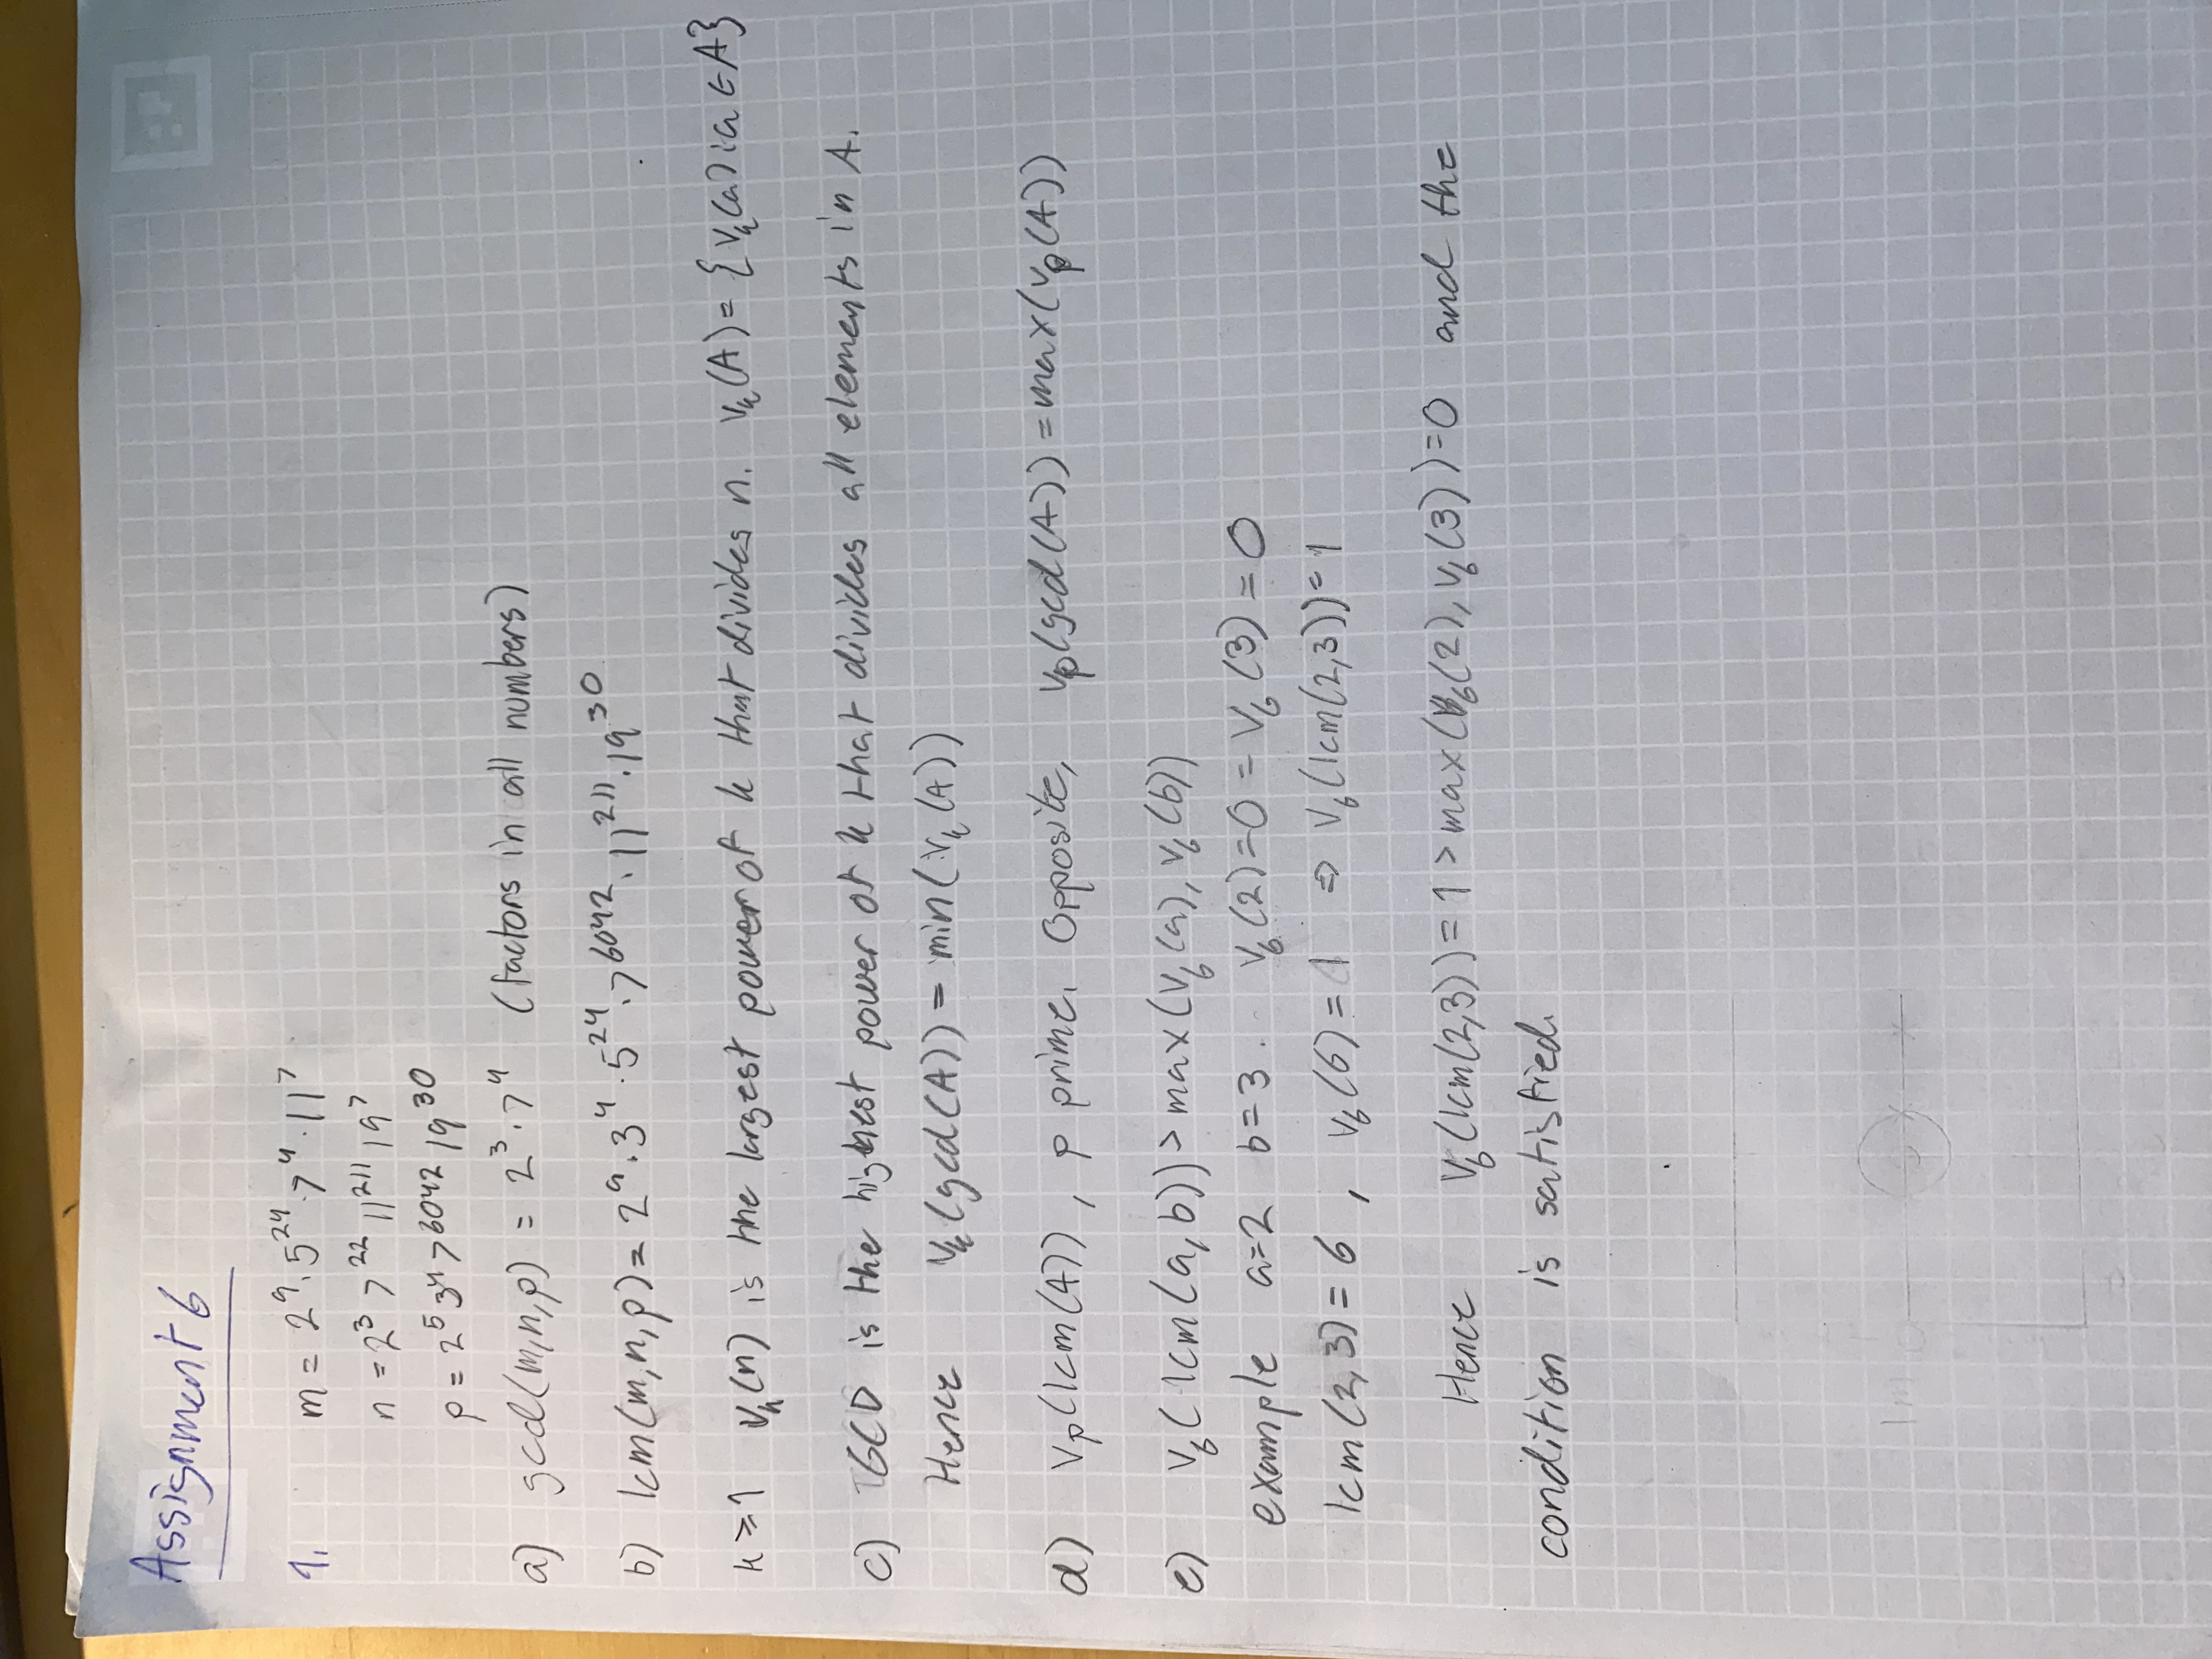

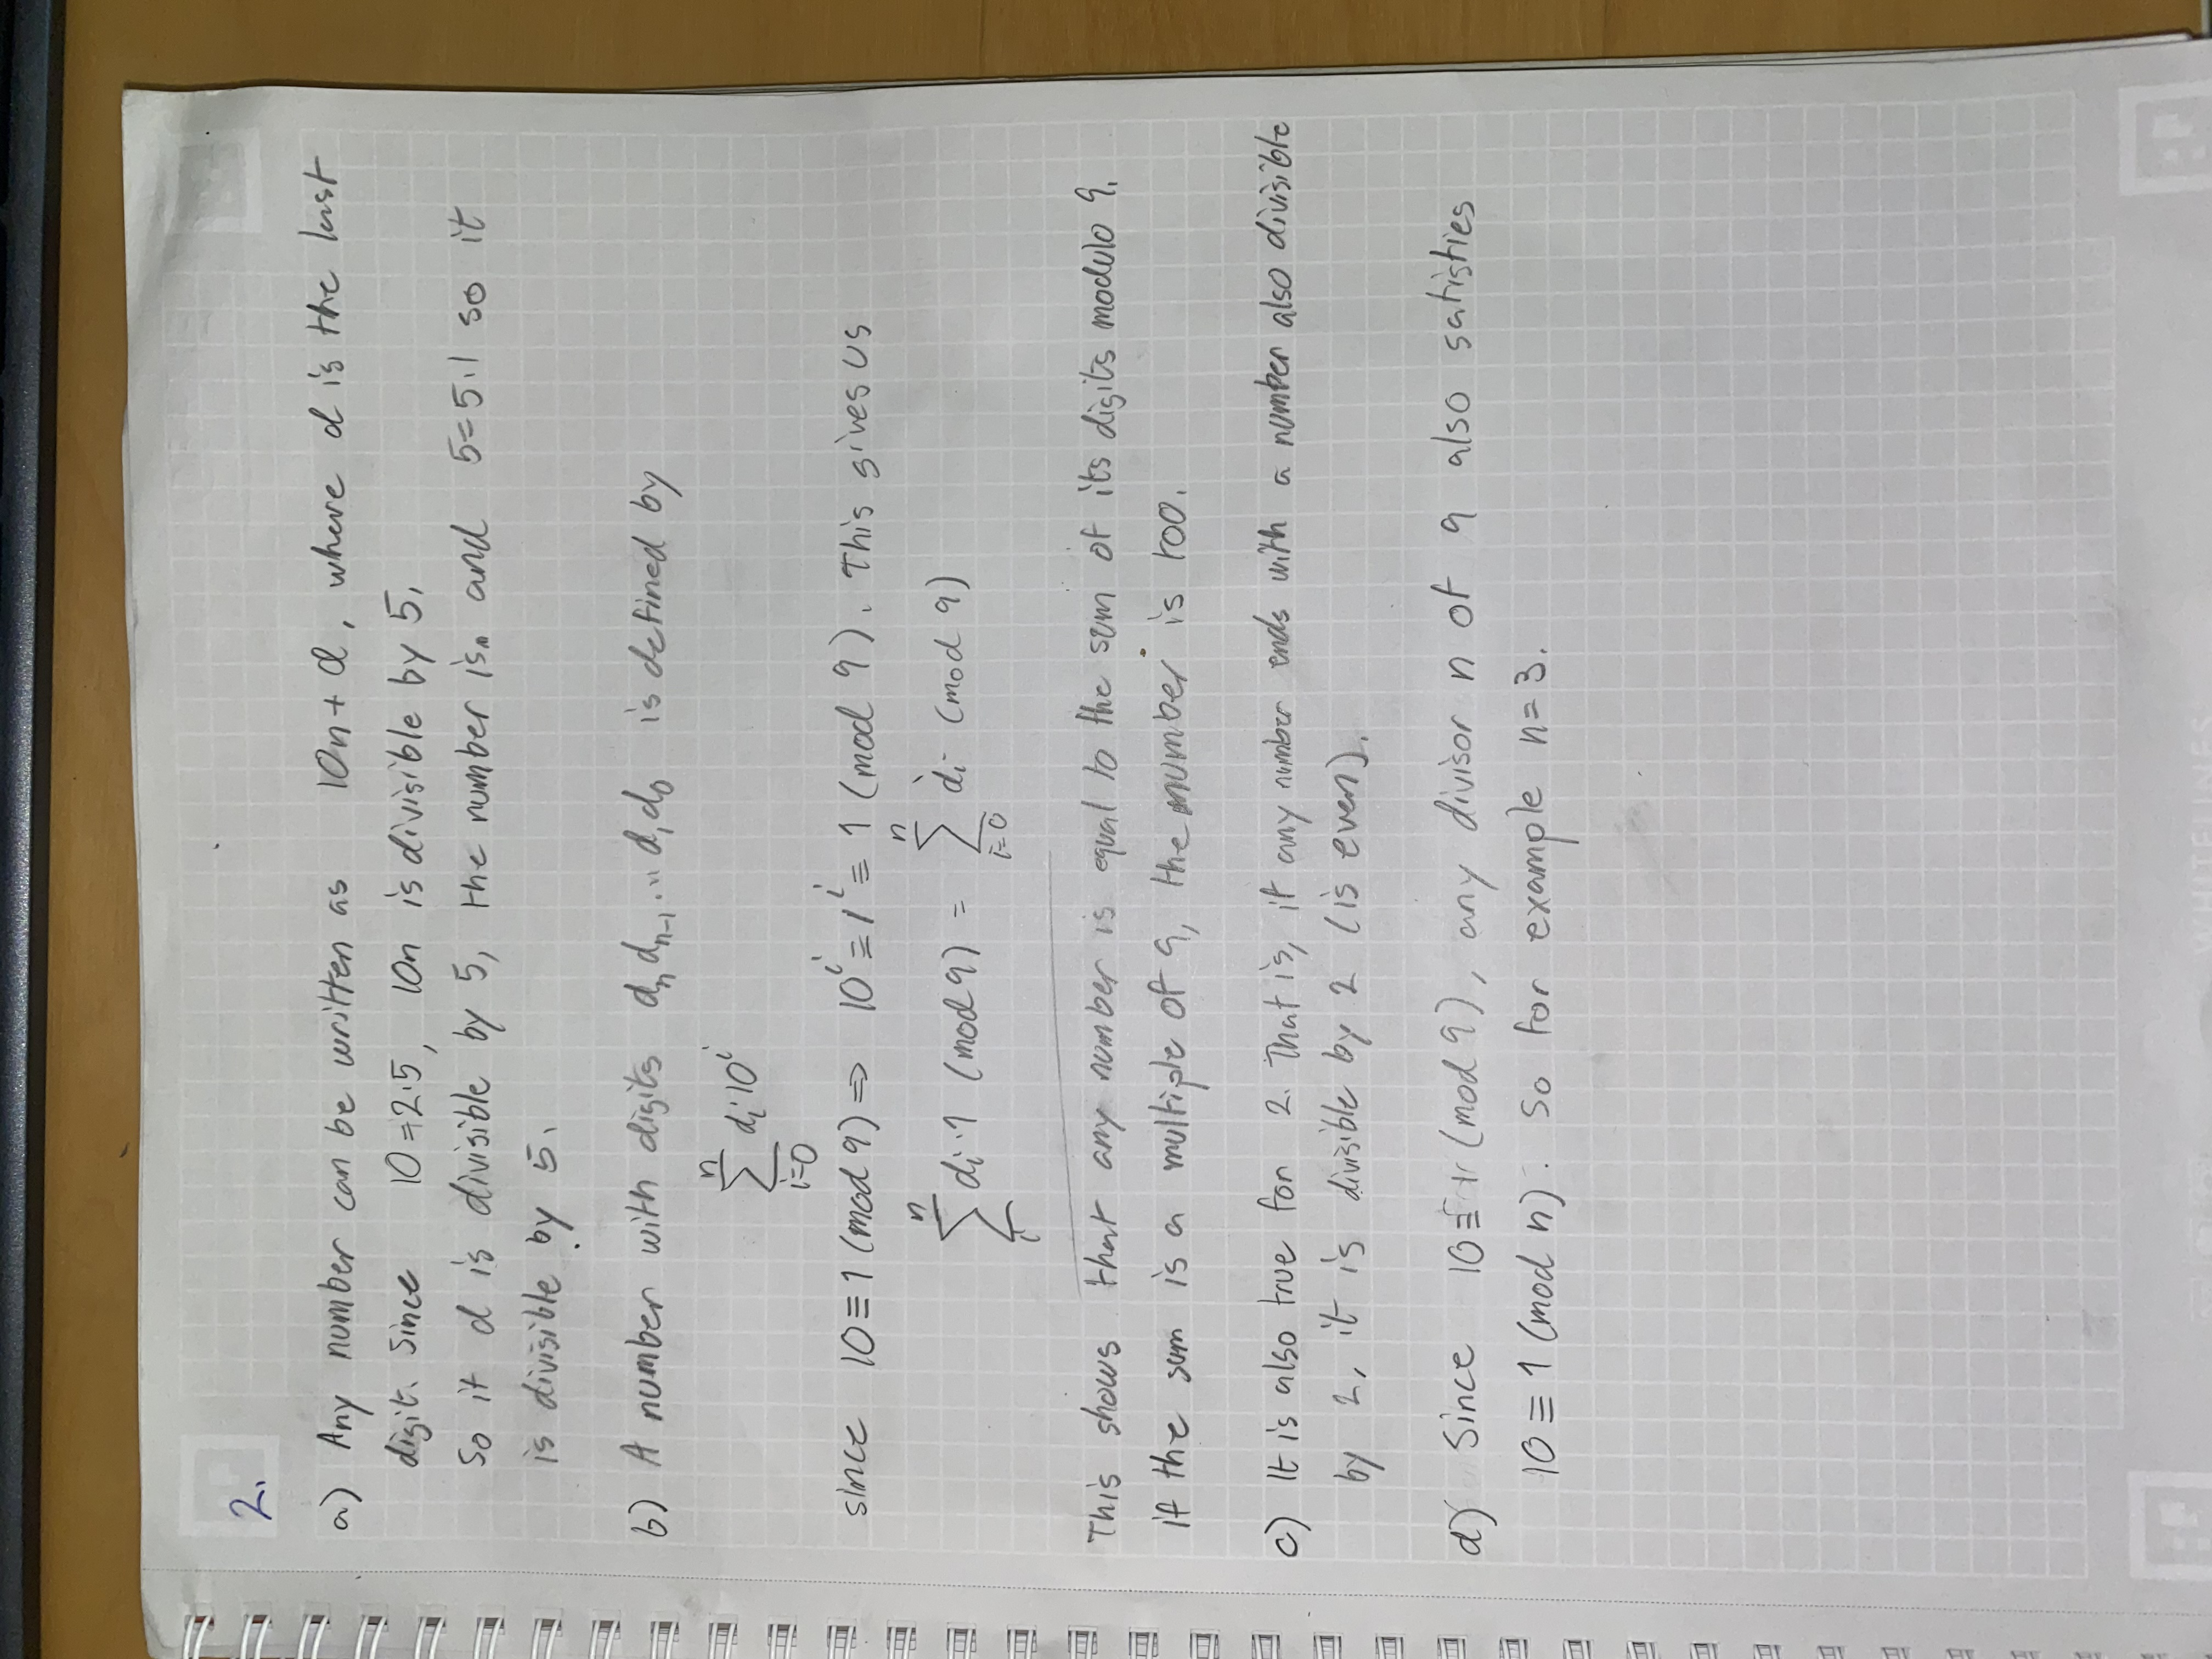

In [1]:
from IPython.display import Image, display

display(Image(filename='IMG_6371.jpeg'))
display(Image(filename='IMG_6372.jpeg'))

### Programming Exercises

*Exercise 1:* Implement Euclid's algorithm as a Python function that takes as input two integers and outputs their greatest common divisor (GCD). 

- Write a short explanation, in your own words, of why Euclid's algorithm computes the gcd of its inputs. Because the gcd(a, b) is the same as gcd(b, a mod b).

- (Based on MIT 9.3) Compute the gcd of the two numbers $x$ and $y$ below by hand using Euclid's algorithm, and then check that your code gives the same answer.

$$x = 21212121, \qquad y = 12121212.$$

 

In [2]:
def euclid(a: int, b: int):
    return a if b == 0 else euclid(b, a % b)

x = 21212121
y = 12121212
print(euclid(x, y))

3030303


*Exercise 2:* In this programming assignment you will explore the *Sieve of Eratosthenes*, an ancient algorithm for finding all prime numbers up to a given limit. 

To find all primes less than or equal to a given integer $n$, the Sieve of Eratosthenes proceeds in the following steps.
1. Create a list $L$ of consecutive integers up to $n$: $L = (2, 3, \ldots, n)$.

2. Initialize $p=2$, the smallest prime number. 

3. Enumerate the multiples of $p$ as $2p, 3p, \ldots, kp$ until $kp>n$. Mark all these numbers in $L$ as not prime. 

4. Find the smallest number in $L$ greater than $p$ which is not marked. If no such number exists, terminate. Otherwise, let $p$ equal this new number and repeat from step $3$.

5. Output all numbers not marked; they are all prime numbers smaller than or equal to $n$.  

**Task 1:** Implement the Sieve of Eratosthenes as a python function `eratosthenes(n)` as described in Steps 1-5 and find the $10$ largest prime numbers that are smaller than $1\;000\;000$. Hint: for better performance, let the list consist of either True or False instead of the numbers themselves, and let the numbers be represented by the index of this Boolean in the list.


In [3]:
import math

def eratosthenes(n):
    primes = [True for i in range(n + 1)]
    primes[0] = primes[1] = False
    
    for p in range(2, n+1):
        if not p:
            continue
        k = 2
        while k * p <= n:
            primes[k*p] = False
            k += 1

    return [i for i in range(len(primes)) if primes[i] is True]

print(eratosthenes(1000000)[-10:])

[999863, 999883, 999907, 999917, 999931, 999953, 999959, 999961, 999979, 999983]


We now discuss two optimizations of the sieve. The first is to halt when $p> \sqrt{n}$. The second is, given $p$, to start enumerating the multiples of $p$ from $p \cdot p$ instead of $2p$.

**Task 2:** Explain why these optimizations do not make the algorithm miss a prime. 

You only need to go up to sqrt(n), because if you have a factor larger than sqrt(n), the other factor would have to be smaller than n. And then you would have already seen it.

same for only enumerating from p * p.

**Task 3:** Implement these optimizations into a new sieve `eratosthenes_opt(n)`. Run both `eratosthenes(n)` and `eratosthenes_opt(n)` on all integers in the list $(1\;000, 10\;000, 100\;000, 1\;000\;000, 10\;000\;000)$ and compare their running times on each instance. You can measure the execution time of a program in Python using the `time` package and the function `time.time()`; see [this link](https://stackoverflow.com/questions/1557571/how-do-i-get-time-of-a-python-programs-execution) for an example. 

In [4]:
import math
import time

def eratosthenes_opt(n):
    primes = [True for i in range(n + 1)]
    primes[0] = primes[1] = False
    
    for p in range(2, math.isqrt(n+1)):
        if not p:
            continue
        k = p
        while k * p <= n:
            primes[k*p] = False
            k += 1

    return [i for i in range(len(primes)) if primes[i] is True]


test_list = [1000, 10000, 100000, 1000000, 10000000]
res_no_opt = []
res_opt = []

start = time.time()
for n in test_list:
    eratosthenes_opt(n)
print(time.time() - start)

start = time.time()
for n in test_list:
    eratosthenes(n)
print(time.time() - start)

6.506789445877075
17.023626565933228



**Task 4:** Which of the optimizations do you think is most significant? Try your hypothesis by modifying your code from Tasks 1 and 3.

Square root